In [1]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

In [2]:
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
from kszcnn.diff_real_cnn_galaxy_positions import *

In [4]:
train_sets, test_sets = get_experiment_sets("diff_real")
title = make_title("1P_p2_2", input_type="position", exp_type="diff_real")

In [5]:
print("SET:", set_name)
print("TRAIN_HALO_FILE:", TRAIN_HALO_FILE)
print("TEST_HALO_FILE:",TEST_HALO_FILE)

SET: 1P_p2_2
TRAIN_HALO_FILE: /home/sucharita/kszCNN/data/groups_090_1P_0.hdf5
TEST_HALO_FILE: /home/sucharita/kszCNN/data/groups_090_1P_p2_2.hdf5


In [6]:
np.random.seed(SEED)
torch.manual_seed(SEED)

In [7]:
# load halos + subhalos
pos_tr, vel_tr, mass_tr, sub_pos_tr, sub_mstar_tr = \
    load_groups_and_subhalos(TRAIN_HALO_FILE)

# build galaxy overdensity field 
density_grid_tr = build_galaxy_density_grid(
    sub_pos_tr,
    sub_mstar_tr,
    Ngrid=128,
    mstar_cut=1e8
)

# smooth 
density_grid_tr = smooth_delta_field(density_grid_tr, SMOOTH_SCALE)

Selected galaxies: 923


In [8]:
pos_te, vel_te, mass_te, sub_pos_te, sub_mstar_te = \
    load_groups_and_subhalos(TEST_HALO_FILE)

density_grid_te = build_galaxy_density_grid(
    sub_pos_te,
    sub_mstar_te,
    Ngrid=128,
    mstar_cut=1e8
)

density_grid_te = smooth_delta_field(density_grid_te, SMOOTH_SCALE)

Selected galaxies: 975


In [9]:
print("Halos:", "train_set:",len(pos_tr), "test_set:",len(pos_te))
print("Subhalos:","train_set:", len(sub_pos_tr), "test_set:",len(sub_pos_te))

Halos: train_set: 20817 test_set: 19183
Subhalos: train_set: 18635 test_set: 17097


In [10]:
#  5. Dataset 
rng = np.random.RandomState(SEED)
train_ds = HaloDatasetGalPos( pos_tr, vel_tr, mass_tr,sub_pos_tr,sub_mstar_tr, mass_cut=MASS_CUT,rng=rng)
test_ds  = HaloDatasetGalPos( pos_te, vel_te, mass_te,sub_pos_te, sub_mstar_te,mass_cut=MASS_CUT, rng=rng)

Selected halos: 547
Selected galaxies: 923
Selected halos: 505
Selected galaxies: 975


In [11]:
# 6. Linear baseline 

vlin_test = compute_vlin_from_delta(
    density_grid_te,
    R_smooth=SMOOTH_SCALE
)

vlin_baseline = vlin_at_halos(
    vlin_test,
    test_ds.halo_pos
)

rho_vlin = pearsonr(test_ds.vz, vlin_baseline)[0]

print("Linear theory correlation (using δg):", rho_vlin)

Linear theory correlation (using δg): 0.778341


In [12]:
#7. Train / validation
idxs = np.arange(len(train_ds))

tr_idx, val_idx = train_test_split(
    idxs,
    test_size=0.2,
    random_state=SEED
)

tr_ds  = Subset(train_ds, tr_idx)
val_ds = Subset(train_ds, val_idx)

In [13]:
#  8. Loaders
tr_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH)
te_loader  = DataLoader(test_ds, batch_size=BATCH)

In [14]:
#  9. Normalize velocity
y_train = np.array([train_ds[i][1] for i in tr_idx])

y_mean = y_train.mean()
y_std  = y_train.std() + 1e-12

print("Velocity mean/std:", y_mean, y_std)

Velocity mean/std: -1.0862699 105.11467


In [15]:
model = CNN().to(DEVICE)

In [16]:
train_model(
        model, tr_loader, val_loader, y_mean, y_std
    )

Epoch 1: Train=5.228e-01 | Val=9.662e-01
Epoch 2: Train=5.057e-01 | Val=9.638e-01
Epoch 3: Train=5.047e-01 | Val=9.689e-01
Epoch 4: Train=5.035e-01 | Val=9.640e-01
Epoch 5: Train=4.994e-01 | Val=9.564e-01
Epoch 6: Train=4.944e-01 | Val=9.664e-01
Epoch 7: Train=4.994e-01 | Val=9.495e-01
Epoch 8: Train=4.877e-01 | Val=9.601e-01
Epoch 9: Train=4.923e-01 | Val=9.570e-01
Epoch 10: Train=4.747e-01 | Val=9.224e-01
Epoch 11: Train=4.652e-01 | Val=9.004e-01
Epoch 12: Train=4.377e-01 | Val=8.411e-01
Epoch 13: Train=3.990e-01 | Val=7.471e-01
Epoch 14: Train=3.559e-01 | Val=8.270e-01
Epoch 15: Train=4.050e-01 | Val=7.345e-01
Epoch 16: Train=3.367e-01 | Val=7.602e-01
Epoch 17: Train=3.273e-01 | Val=6.751e-01
Epoch 18: Train=3.297e-01 | Val=6.260e-01
Epoch 19: Train=2.783e-01 | Val=7.478e-01
Epoch 20: Train=2.970e-01 | Val=7.527e-01
Epoch 21: Train=2.763e-01 | Val=5.965e-01
Epoch 22: Train=2.650e-01 | Val=7.116e-01
Epoch 23: Train=2.971e-01 | Val=6.591e-01
Epoch 24: Train=2.664e-01 | Val=6.189e-01
E

CNN(
  (conv): Sequential(
    (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): GroupNorm(8, 64, eps=1e-05, affine=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): GroupNorm(8, 128, eps=1e-05, affine=True)
    (10): ReLU()
    (11): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool3d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)


===== TEST RESULTS =====
RMSE = 84.10
corr.coef r = 0.75
m = 0.50
b = 7.66
metric_val = 0.35


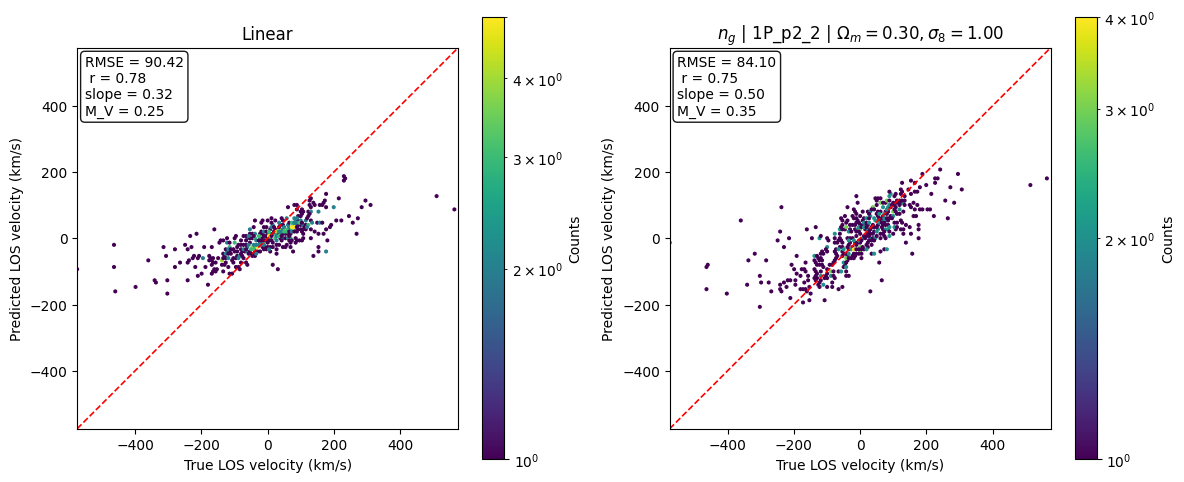

In [17]:
evaluate_model(
        model, te_loader, test_ds,
        y_mean, y_std,
        vlin_baseline, rho_vlin
    )